In [1]:
import time
import torch
import random
import math
import os

from glob import glob
from typing import Iterable
import numpy as np
from scipy.io import loadmat
import seaborn as sns
from sklearn.decomposition import PCA

from torch import nn, Tensor, optim
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt
from matplotlib import cm

In [2]:
# To avoide meshgrid warning
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module='torch')

In [3]:
if torch.cuda.is_available():
    device = 'cuda:0'
    print('Using gpu')
else:
    device = 'cpu'
    print('Using cpu.')

Using cpu.


In [4]:
torch.manual_seed(42)

In [5]:
class Swish(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, x: Tensor) -> Tensor: 
        return torch.sigmoid(x) * x


#MLP
class MLP(nn.Module):
    def __init__(self, input_dim: int = 2, time_dim: int = 1, hidden_dim: int = 128):
        super().__init__()
        
        self.input_dim = input_dim
        self.time_dim = time_dim
        self.hidden_dim = hidden_dim

        self.main = nn.Sequential(
            nn.Linear(input_dim+input_dim+time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, input_dim),
            )
    

    def forward(self, x: Tensor, cond: Tensor, t: Tensor) -> Tensor:
        
        #print("INSIDE")
        sz = x.size()
        #print(x.shape)
        x = x.reshape(-1, self.input_dim)
        #print(x.shape)
        t = t.reshape(-1, self.time_dim).float()
        #print(t.shape)
        f = cond.reshape(-1, self.input_dim)

        t = t.reshape(-1, 1).expand(x.shape[0], 1)
        h = torch.cat([x, f, t], dim=1)
        output = self.main(h)
        
        return output.reshape(*sz)


#ConvNet
class ConvFlow(nn.Module):
    def __init__(self, input_dim: int = 64, hidden_dim: int = 64, time_dim: int = 1):
        super().__init__()

        self.input_dim = input_dim
        self.hidden_dim = hidden_dim

        # --- time embedding (scalar t → hidden_dim vector)
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, hidden_dim),
            Swish(),
            nn.Linear(hidden_dim, hidden_dim)
        )

        # --- CNN ---
        self.conv_in = nn.Conv2d(2, hidden_dim, 3, padding=1)  # (x,f)
        self.conv1 = nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1)
        self.conv2 = nn.Conv2d(hidden_dim, hidden_dim, 3, padding=1)
        self.conv_out = nn.Conv2d(hidden_dim, 1, 3, padding=1)

        self.act = Swish()

    def forward(self, x: Tensor, cond: Tensor, t: Tensor) -> Tensor:
        # reshape inputs if needed
        if x.dim() == 2:
            x = x.view(x.size(0), 1, self.input_dim, self.input_dim)
        if cond.dim() == 2:
            f = cond.view(cond.size(0), 1, self.input_dim, self.input_dim)

        B, _, H, W = x.shape

        # --- (x,f) concat spatially ---
        h = torch.cat([x, f], dim=1)  # (B, 2, H, W)
        h = self.act(self.conv_in(h))

        # --- compute time embedding ---
        t_emb = self.time_mlp(t)  # (B, hidden_dim)
        t_emb = t_emb[:, :, None, None]  # (B, hidden_dim, 1, 1)
        # this is broadcastable to (B, hidden_dim, H, W)

        # --- residual-like time conditioning ---
        h = h + t_emb
        h = self.act(self.conv1(h))
        h = self.act(self.conv2(h))

        out = self.conv_out(h)
        return out.view(B, -1)



In [6]:
# --- Basic conv block ---
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            Swish(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            Swish(),
        )

    def forward(self, x): 
        return self.block(x)


# --- UNet with conditioning (x, f) and time embedding (t) ---
class UNetFlow(nn.Module):
    """U-Net that automatically sets depth based on input_dim, conditioned on f and time t."""
    def __init__(self, input_dim: int = 64, base_ch: int = 64, time_dim: int = 1):
        super().__init__()
        self.input_dim = input_dim
        self.base_ch   = base_ch

        # --- time embedding ---
        self.time_mlp = nn.Sequential(
            nn.Linear(time_dim, base_ch),
            Swish(),
            nn.Linear(base_ch, base_ch)
        )

        # --- Determine depth automatically ---
        max_depth = int(math.floor(math.log2(input_dim))) - 1  # e.g. 64→5, 128→6
        self.max_depth = max_depth

        # --- Encoder ---
        self.downs, self.pools = nn.ModuleList(), nn.ModuleList()
        in_ch = 2  # x + f channels
        for i in range(max_depth):
            out_ch = base_ch * min(2 ** i, 16)  # cap growth
            self.downs.append(ConvBlock(in_ch, out_ch))
            self.pools.append(nn.MaxPool2d(2))
            in_ch = out_ch

        # --- Bottleneck ---
        self.bottleneck = ConvBlock(in_ch, in_ch * 2)

        # --- Decoder ---
        self.ups, self.up_blocks = nn.ModuleList(), nn.ModuleList()
        rev_chs = [block.block[0].out_channels for block in self.downs[::-1]]
        curr_ch = self.bottleneck.block[0].out_channels
        for skip_ch in rev_chs:
            self.ups.append(nn.ConvTranspose2d(curr_ch, skip_ch, 2, stride=2))
            self.up_blocks.append(ConvBlock(skip_ch * 2, skip_ch))
            curr_ch = skip_ch

        self.out_conv = nn.Conv2d(base_ch, 1, 3, padding=1)

        # --- time projection for residual addition ---
        self.time_proj = nn.ModuleList([
            nn.Linear(base_ch, ch.block[0].out_channels) for ch in self.downs + [self.bottleneck] + self.up_blocks
        ])

    def forward(self, x: Tensor, f: Tensor, t: Tensor) -> Tensor:
        if x.dim() == 2:
            side = int(x.size(1) ** 0.5)
            x = x.view(x.size(0), 1, side, side)
        if f.dim() == 2:
            side = int(f.size(1) ** 0.5)
            f = f.view(f.size(0), 1, side, side)

        B, _, H, W = x.shape
        t_emb = self.time_mlp(t)  # (B, base_ch)

        # --- Encoder ---
        h = torch.cat([x, f], dim=1)
        skips = []
        for i, (down, pool) in enumerate(zip(self.downs, self.pools)):
            h = down(h)
            h = h + self.time_proj[i](t_emb)[:, :, None, None]  # add time conditioning
            skips.append(h)
            if h.shape[-2] > 1 and h.shape[-1] > 1:
                h = pool(h)

        # --- Bottleneck ---
        h = self.bottleneck(h)
        h = h + self.time_proj[len(self.downs)](t_emb)[:, :, None, None]

        # --- Decoder ---
        for j, (up, block, skip) in enumerate(zip(self.ups, self.up_blocks, reversed(skips))):
            h = up(h)
            if h.shape[-2:] != skip.shape[-2:]:
                h = nn.functional.interpolate(h, size=skip.shape[-2:], mode="bilinear", align_corners=False)
            h = torch.cat([h, skip], dim=1)
            h = block(h)
            idx = len(self.downs) + 1 + j
            h = h + self.time_proj[idx](t_emb)[:, :, None, None]

        out = self.out_conv(h)
        return out.view(B, -1)


In [7]:
class PoissonDataset(Dataset):
    def __init__(self, data_path, normalize=True, n_samples_for_stats=None):
        
        data = loadmat(data_path)
        phi = data["phi_data"].astype("float32")  # (N, 64, 64)
        f   = data["f_data"].astype("float32")

        if normalize:
            u_mean, u_std = phi.mean(), phi.std() + 1e-8
            f_mean, f_std = f.mean(),   f.std() + 1e-8
            phi = (phi - u_mean) / u_std
            f   = (f   - f_mean) / f_std
        
        self.u = torch.from_numpy(phi).contiguous()
        self.f = torch.from_numpy(f).contiguous()
        
    def __len__(self): return self.u.shape[0]

    def __getitem__(self, index):

        return self.u[index], self.f[index]

In [8]:
@torch.no_grad()
def visualize_flow_evolution(model, val_loader, fig_path, n_steps=10, device='cuda'):
    model.eval()

    u, f = next(iter(val_loader))
    u    = u.flatten(start_dim=1).float().to(device)
    f    = f.flatten(start_dim=1).float().to(device)
    x_0  = torch.randn((f.flatten(start_dim=1).shape)).to(device)

    n_samples = min(4, f.shape[0])       
    dim = f.shape[1]
    H = W = int(dim**0.5)                #
    t_vals = torch.linspace(0, 1, n_steps + 2, device=device)

    fig, axes = plt.subplots(n_samples, len(t_vals), figsize=(2.5*len(t_vals), 2.5*n_samples))
    if n_samples == 1:
        axes = axes.unsqueeze(0)

    for i in range(n_samples):
        x_t = x_0[i].unsqueeze(0) 

        for j, t in enumerate(t_vals):
            if j == 0:
                x_plot = f[i]
                title = "condition (f)"
            elif j == len(t_vals) - 1:
                x_plot = u[i]
                title = "t=1 (u) gt"
            elif j == len(t_vals) -2:
                dt = t_vals[-1] - t_vals[-2]          
                t_last = t_vals[-2]
                t_next = t_vals[-1]
                v_t = model(x_t, f[i] , t_last.repeat(x_t.size(0), 1))
                x_t = x_t + dt * v_t  
                x_plot = x_t.squeeze(0)
                title = "t=1 (u) pred"
            else:
                # One Euler step: x_{t+dt} = x_t + dt * v(x_t, t)
                dt = t_vals[j] - t_vals[j-1]
                t_mid = (t_vals[j] + t_vals[j-1]) / 2
                v_t = model(x_t, f[i], t_mid.repeat(x_t.size(0), 1))
                x_t = x_t + dt * v_t
                x_plot = x_t.squeeze(0)
                title = f"t={t.item():.2f}"

            ax = axes[i, j]
            ax.imshow(x_plot.view(H, W).cpu(), cmap='viridis')
            ax.axis('off')
            if i == 0:
                ax.set_title(title, fontsize=9)

    plt.tight_layout()
    plt.show()
    plt.savefig(fig_path, dpi=200, bbox_inches="tight")
    plt.close()


In [9]:
poisson_train = glob("/Users/sarperyurtseven/Desktop/sarper/FlowPDE/data/static/poisson/*32*train*")[0]
poisson_val   = glob("/Users/sarperyurtseven/Desktop/sarper/FlowPDE/data/static/poisson/*32*val*")[0]
poisson_train_dataset = PoissonDataset(data_path = poisson_train)
poisson_val_dataset   = PoissonDataset(data_path = poisson_val)

In [10]:
train_loader = DataLoader(dataset=poisson_train_dataset, 
                          batch_size=512,
                          shuffle=True)
val_loader = DataLoader(dataset=poisson_val_dataset, 
                          batch_size=512,
                          shuffle=True)

In [11]:
print("Train samples:", len(poisson_train_dataset))
print("Val samples:", len(poisson_val_dataset))

u, f = poisson_train_dataset[0]
print("u shape:", u.shape)
print("f shape:", f.shape)
print("u dtype:", u.dtype)
print("f dtype:", f.dtype)

Train samples: 2000
Val samples: 500
u shape: torch.Size([32, 32])
f shape: torch.Size([32, 32])
u dtype: torch.float32
f dtype: torch.float32


In [12]:
def describe_tensor(tensor):
    return {
        "min": tensor.min().item(),
        "max": tensor.max().item(),
        "mean": tensor.mean().item(),
        "std": tensor.std().item()
    }

u_stats = describe_tensor(u)
f_stats = describe_tensor(f)
print("u stats:", u_stats)
print("f stats:", f_stats)


u stats: {'min': -2.663383960723877, 'max': 2.6237850189208984, 'mean': -0.043046679347753525, 'std': 1.1591506004333496}
f stats: {'min': -3.794473886489868, 'max': 3.7133796215057373, 'mean': 9.313225746154785e-09, 'std': 1.479250192642212}


In [13]:
def dataset_stats(dataset, n_samples=100):
    u_means, f_means = [], []
    for i in range(min(len(dataset), n_samples)):
        u, f = dataset[i]
        u_means.append(u.mean().item())
        f_means.append(f.mean().item())
    print("u mean mean:", sum(u_means)/len(u_means))
    print("f mean mean:", sum(f_means)/len(f_means))

dataset_stats(poisson_train_dataset)


u mean mean: -0.02296927893999964
f mean mean: 7.799826562404633e-10


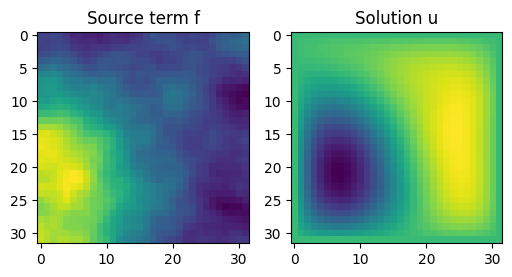

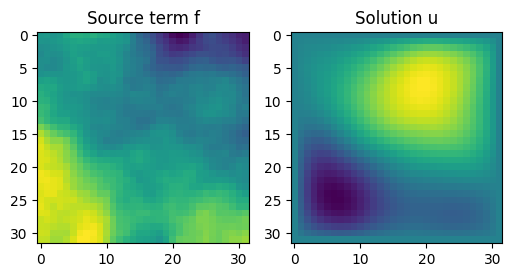

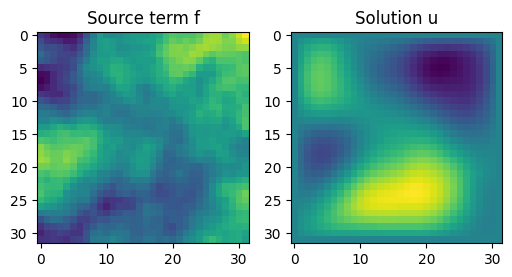

In [14]:
for i in random.sample(range(len(poisson_train_dataset)), 3):
    u, f = poisson_train_dataset[i]
    fig, ax = plt.subplots(1, 2, figsize=(6,3))
    ax[0].imshow(f, cmap='viridis'); ax[0].set_title("Source term f")
    ax[1].imshow(u, cmap='viridis'); ax[1].set_title("Solution u")
    plt.show()

In [ ]:
# Collect samples
U, F = [], []
n_samples = min(200, len(poisson_train_dataset))

for i in range(n_samples):
    u, f = poisson_train_dataset[i]
    U.append(u.flatten())
    F.append(f.flatten())

U = np.stack(U)
F = np.stack(F)

# --- Fit PCA on combined data ---
X = np.concatenate([U, F], axis=0)
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X)

# Split back
u_2d = X_2d[:len(U)]
f_2d = X_2d[len(U):]

# --- Plot together ---
plt.figure(figsize=(6,5))
plt.scatter(u_2d[:,0], u_2d[:,1], s=15, color='blue', alpha=0.6, label='Solutions (u)')
plt.scatter(f_2d[:,0], f_2d[:,1], s=15, color='red', alpha=0.6, label='Sources (f)')
plt.legend()
plt.title("PCA projection of Poisson samples (u vs f)")
plt.xlabel("PC 1"); plt.ylabel("PC 2")
plt.show()


In [18]:
def train(
    model: nn.Module, 
    data_loader: Iterable, 
    optimizer: optim.Optimizer, 
    lr_schedule: optim.lr_scheduler.LRScheduler, 
    device: torch.device,
    epochs: int,
    max_grad_norm: float = 1.0,
    save_interval: int = 20000,
    save_dir: str = "checkpoints"
):
    for epoch in range(epochs):
        start_time = time.time()
        train_loss = train_one_epoch(
            model=model,
            data_loader=data_loader,
            optimizer=optimizer,
            lr_schedule=lr_schedule,
            device=device,
            epoch=epoch,
            max_grad_norm=max_grad_norm,
        )

        lr_schedule.step()
        elapsed = time.time() - start_time
        
        if epoch % 300 == 0 or epoch == epochs - 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(
                f"[Epoch {epoch+1:04d}/{epochs}] "
                f"Train Loss: {train_loss:.10f} | "
                f"LR: {current_lr:.2e} | "
                f"Time: {elapsed:.2f}s"
            )

        if (epoch % save_interval == 0 and epoch != 0) or epoch == epochs - 1:
            os.makedirs(save_dir, exist_ok=True)
            ckpt_path = os.path.join(save_dir, f"poisson_flowmatching_epoch_{epoch+1}.pt")
            torch.save({
                "epoch": epoch + 1,
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "scheduler_state": lr_schedule.state_dict(),
                "train_loss": train_loss,
            }, ckpt_path)

            vis_dir = os.path.join(save_dir, "visualizations")
            os.makedirs(vis_dir, exist_ok=True)
            fig_path = os.path.join(vis_dir, f"poisson_flowmatching_epoch_{epoch+1:05d}.png")
            visualize_flow_evolution(model, val_loader, fig_path, n_steps=8, device=device)

In [19]:
def train_one_epoch(
    model: nn.Module, 
    data_loader: Iterable, 
    optimizer: optim.Optimizer, 
    lr_schedule: optim.lr_scheduler.LRScheduler, 
    device: torch.device,
    epoch: int,
    max_grad_norm: float = 1.0,
):
    model.train()
    train_loss = 0.0

    for batch_idx, (u, f) in enumerate(data_loader):
        optimizer.zero_grad()

        x_1  = u.flatten(start_dim=1).to(device)
        x_0  = torch.randn((f.flatten(start_dim=1).shape)).to(device)
        cond = f.flatten(start_dim=1).to(device)
        t    = torch.rand((f.shape[0],1), device=device)  

        # print(x_0.shape)
        # print(t.shape)
        # Sample from  path
        x_t  = (1 - t) * x_0 + t * x_1
        dx_t = x_1 - x_0
        
        # Compute loss
        loss = ((model(x_t, cond, t) - dx_t) ** 2).mean()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)

        loss.backward()
        optimizer.step()
        
        train_loss += loss.detach()

    train_loss = train_loss / len(data_loader)
    train_loss = train_loss.item() 
    return train_loss

In [20]:
poisson_train_dataset = PoissonDataset(data_path = poisson_train)
poisson_val_dataset   = PoissonDataset(data_path = poisson_val)

In [21]:
train_loader = DataLoader(
    poisson_train_dataset,
    batch_size=512,                 
    shuffle=True,
    num_workers=0,                            
)
val_loader = DataLoader(
    poisson_val_dataset,
    batch_size=512,
    shuffle=False,
    num_workers=0,
)


In [23]:
flow = MLP(input_dim=32**2, 
            hidden_dim=1024)
flow = flow.to(device)
optimizer = torch.optim.Adam(flow.parameters(), 
                       lr=3e-4)
epochs = 10000
loss_fn = nn.MSELoss()
lr_schedule = optim.lr_scheduler.CosineAnnealingLR(
    optimizer, 
    T_max=epochs, 
    eta_min=1e-5
)

In [26]:
epochs = 80000

[Epoch 0001/80000] Train Loss: 0.5045636296 | LR: 1.00e-05 | Time: 0.24s
[Epoch 0301/80000] Train Loss: 0.5090529919 | LR: 1.06e-05 | Time: 0.14s
[Epoch 0601/80000] Train Loss: 0.5060497522 | LR: 1.26e-05 | Time: 0.14s
[Epoch 0901/80000] Train Loss: 0.5125005245 | LR: 1.58e-05 | Time: 0.14s
[Epoch 1201/80000] Train Loss: 0.5133689642 | LR: 2.02e-05 | Time: 0.14s
[Epoch 1501/80000] Train Loss: 0.5124838352 | LR: 2.58e-05 | Time: 0.14s
[Epoch 1801/80000] Train Loss: 0.5086021423 | LR: 3.26e-05 | Time: 0.14s
[Epoch 2101/80000] Train Loss: 0.5069898963 | LR: 4.05e-05 | Time: 0.14s
[Epoch 2401/80000] Train Loss: 0.5125421882 | LR: 4.93e-05 | Time: 0.14s
[Epoch 2701/80000] Train Loss: 0.5050184131 | LR: 5.91e-05 | Time: 0.14s
[Epoch 3001/80000] Train Loss: 0.5052646399 | LR: 6.98e-05 | Time: 0.14s
[Epoch 3301/80000] Train Loss: 0.5029762983 | LR: 8.12e-05 | Time: 0.14s
[Epoch 3601/80000] Train Loss: 0.5131439567 | LR: 9.33e-05 | Time: 0.14s
[Epoch 3901/80000] Train Loss: 0.5065085888 | LR: 1

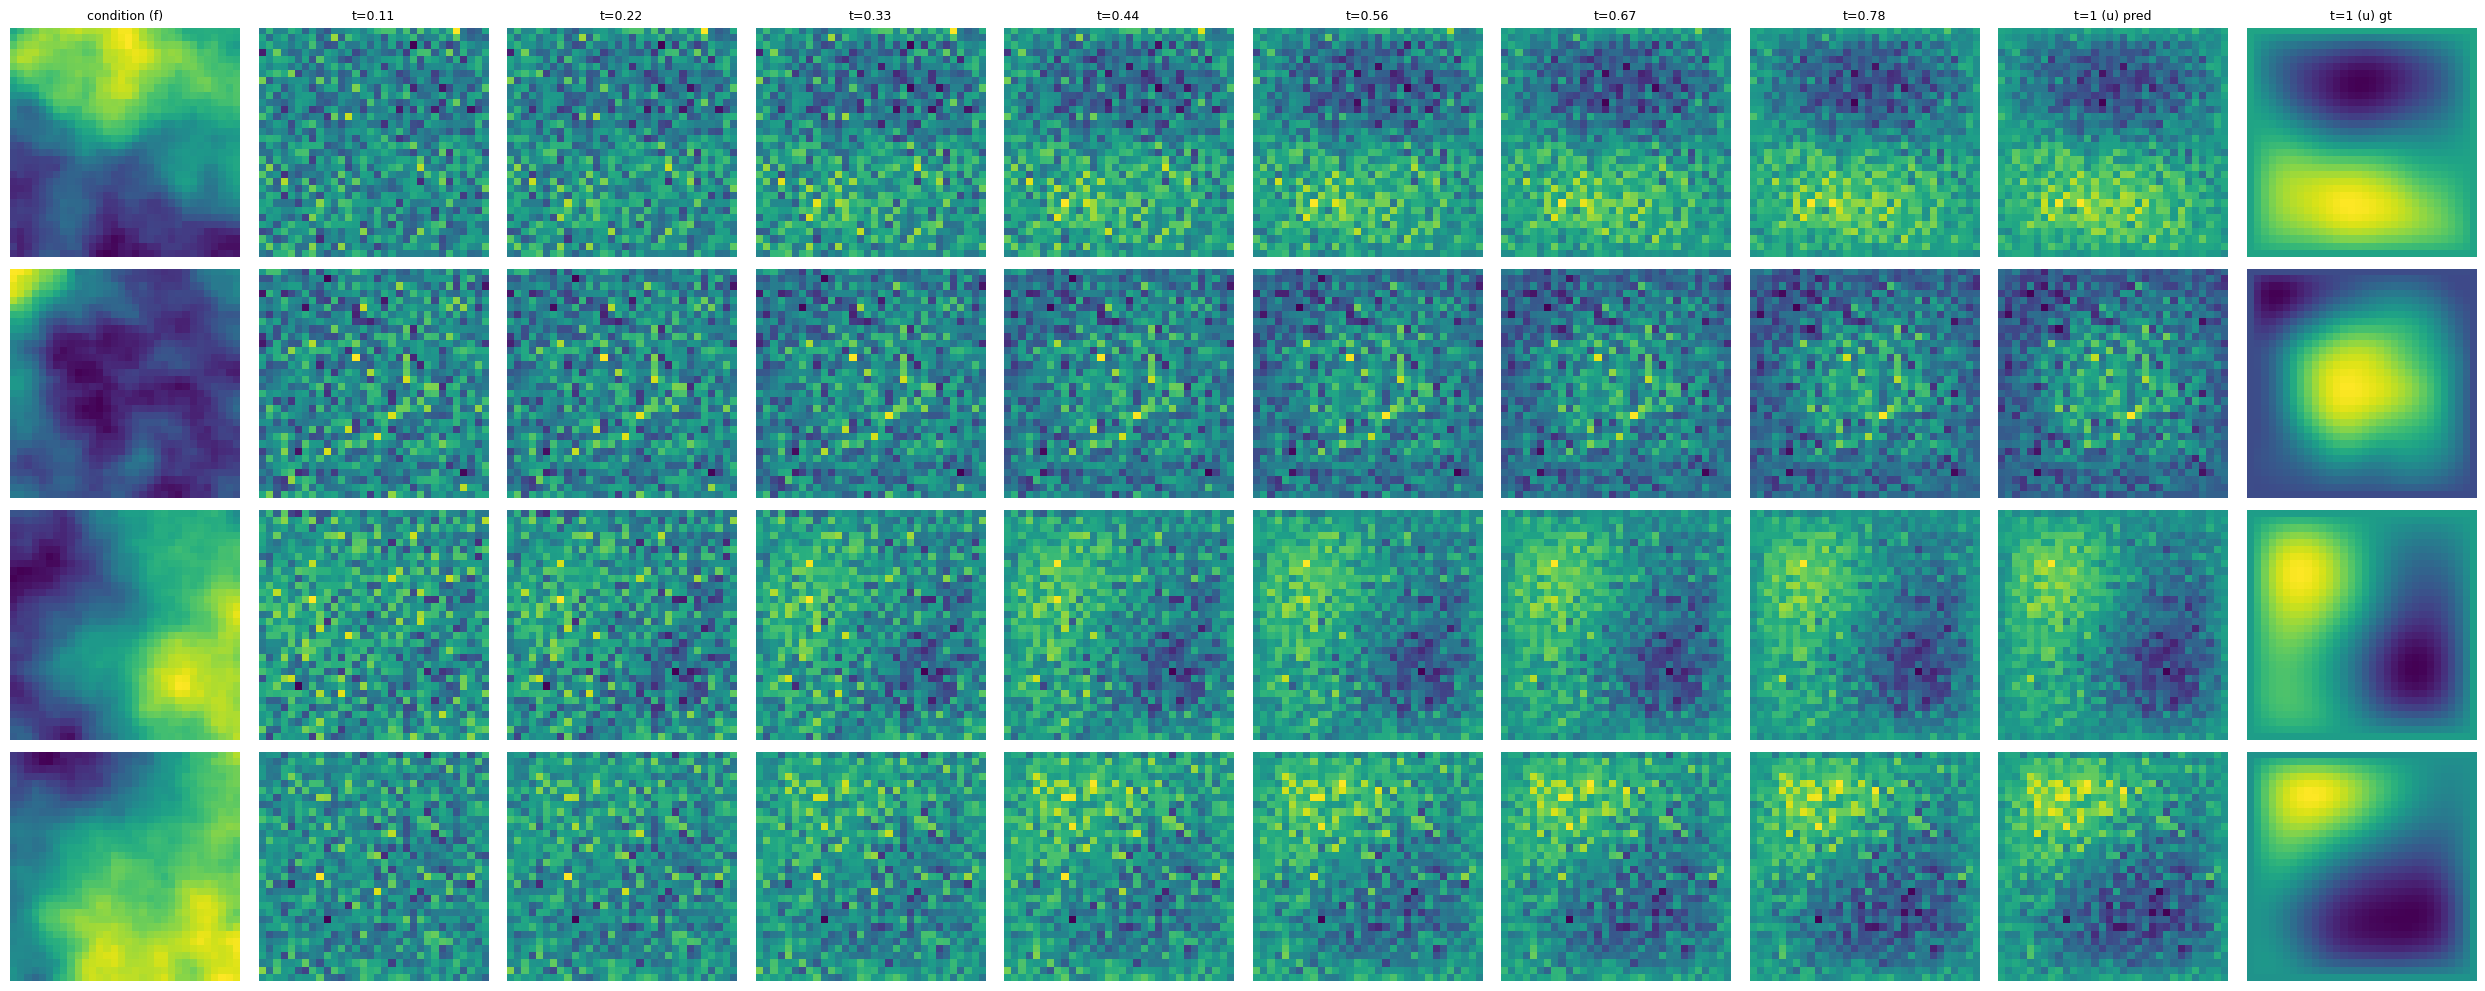

[Epoch 20101/80000] Train Loss: 0.4320506752 | LR: 1.01e-05 | Time: 0.14s
[Epoch 20401/80000] Train Loss: 0.4320766330 | LR: 1.11e-05 | Time: 0.14s
[Epoch 20701/80000] Train Loss: 0.4401126206 | LR: 1.35e-05 | Time: 0.14s
[Epoch 21001/80000] Train Loss: 0.4310279787 | LR: 1.71e-05 | Time: 0.14s
[Epoch 21301/80000] Train Loss: 0.4368875623 | LR: 2.19e-05 | Time: 0.14s
[Epoch 21601/80000] Train Loss: 0.4344591796 | LR: 2.80e-05 | Time: 0.14s
[Epoch 21901/80000] Train Loss: 0.4404747188 | LR: 3.51e-05 | Time: 0.14s
[Epoch 22201/80000] Train Loss: 0.4332734942 | LR: 4.33e-05 | Time: 0.14s
[Epoch 22501/80000] Train Loss: 0.4349072874 | LR: 5.25e-05 | Time: 0.14s
[Epoch 22801/80000] Train Loss: 0.4394354224 | LR: 6.26e-05 | Time: 0.14s
[Epoch 23101/80000] Train Loss: 0.4393077195 | LR: 7.35e-05 | Time: 0.14s
[Epoch 23401/80000] Train Loss: 0.4396715164 | LR: 8.52e-05 | Time: 0.14s
[Epoch 23701/80000] Train Loss: 0.4389239550 | LR: 9.75e-05 | Time: 0.14s
[Epoch 24001/80000] Train Loss: 0.4451

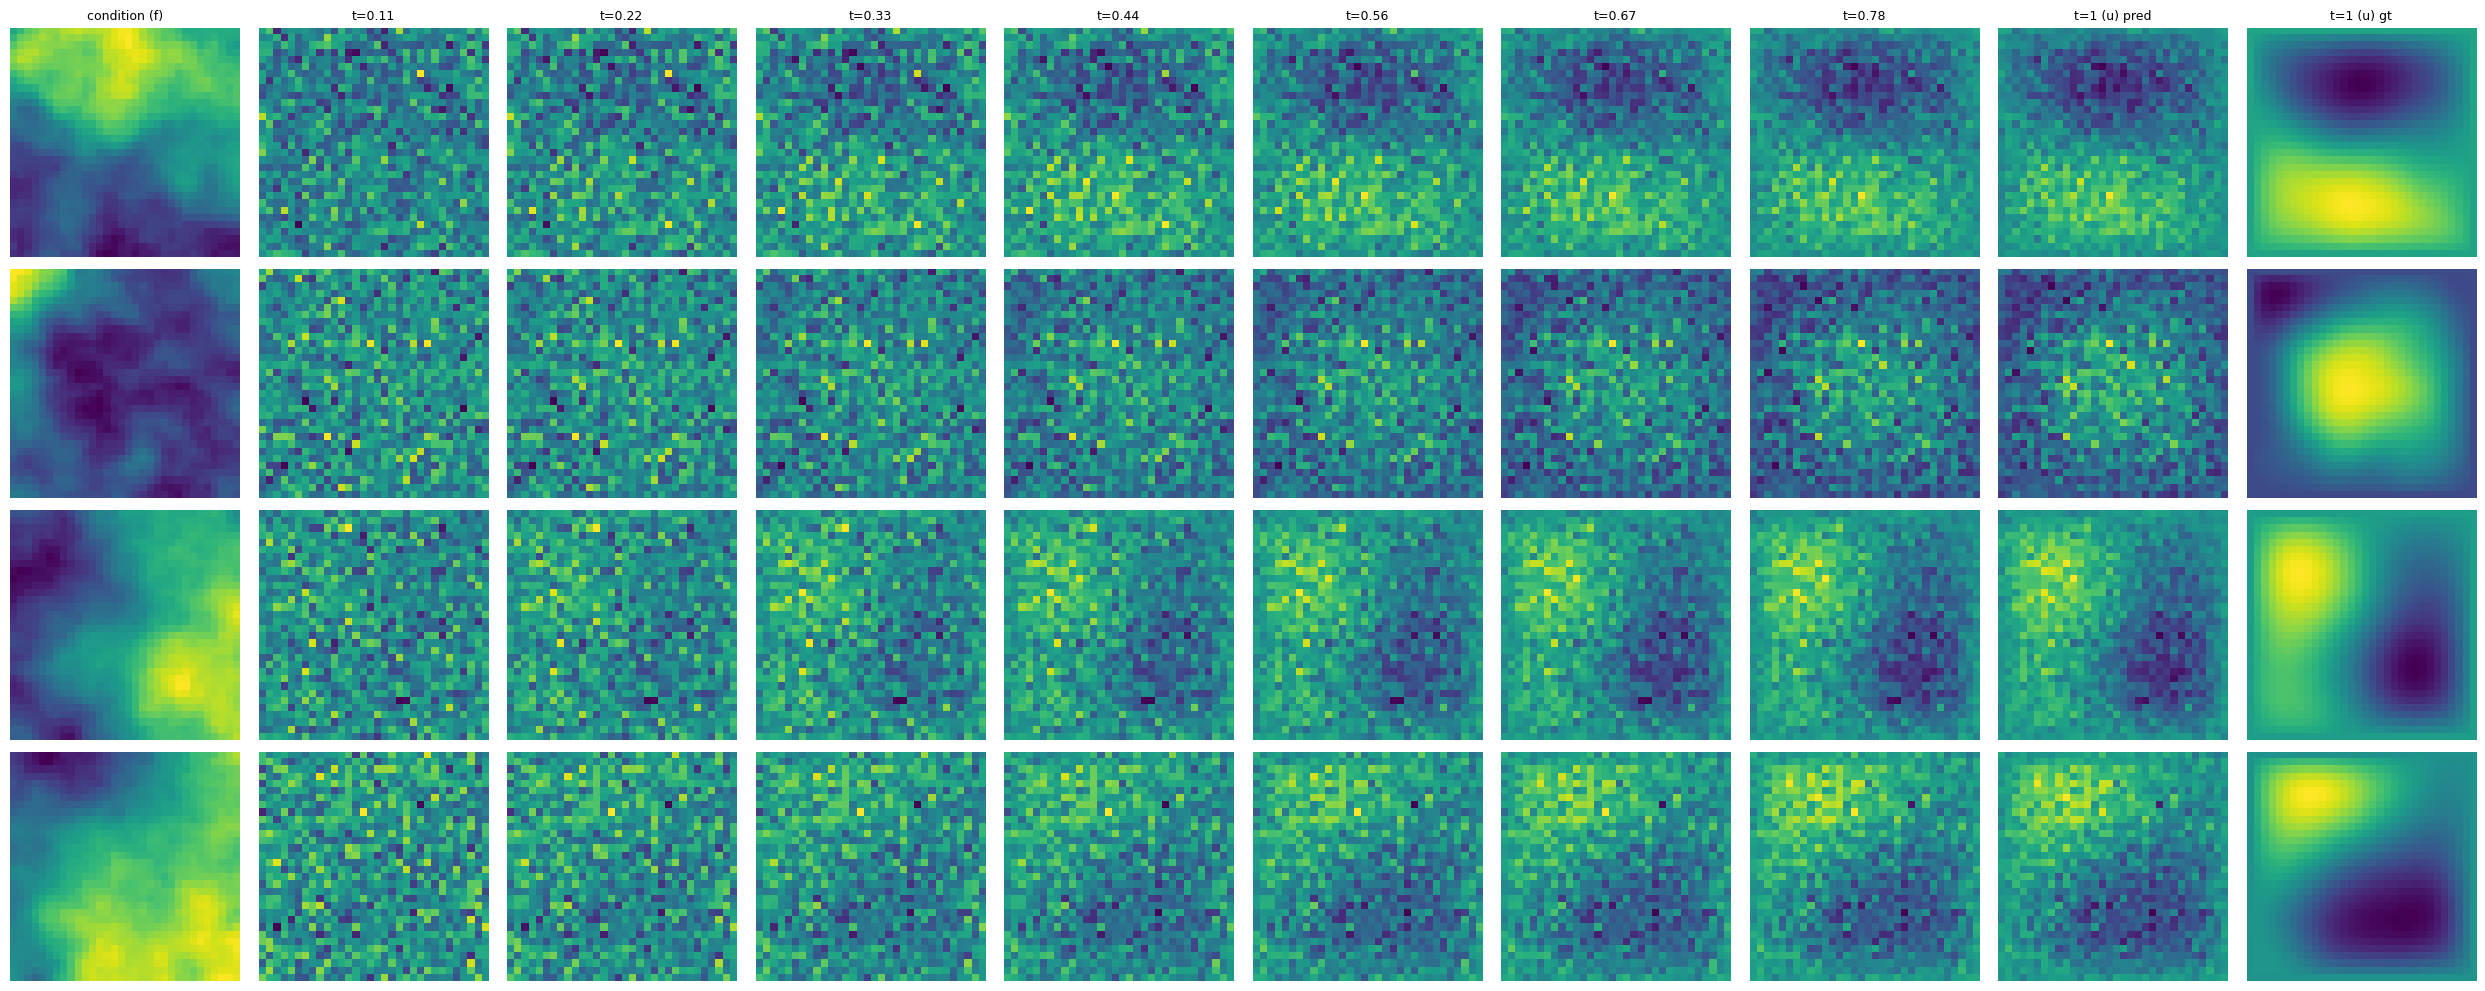

[Epoch 40201/80000] Train Loss: 0.4106891155 | LR: 1.03e-05 | Time: 0.14s
[Epoch 40501/80000] Train Loss: 0.4095950425 | LR: 1.18e-05 | Time: 0.14s
[Epoch 40801/80000] Train Loss: 0.4103902280 | LR: 1.46e-05 | Time: 0.14s
[Epoch 41101/80000] Train Loss: 0.4132840037 | LR: 1.86e-05 | Time: 0.14s
[Epoch 41401/80000] Train Loss: 0.4194290042 | LR: 2.38e-05 | Time: 0.14s
[Epoch 41701/80000] Train Loss: 0.4120844305 | LR: 3.02e-05 | Time: 0.14s
[Epoch 42001/80000] Train Loss: 0.4167442024 | LR: 3.77e-05 | Time: 0.14s
[Epoch 42301/80000] Train Loss: 0.4186305106 | LR: 4.63e-05 | Time: 0.14s
[Epoch 42601/80000] Train Loss: 0.4182409644 | LR: 5.58e-05 | Time: 0.14s
[Epoch 42901/80000] Train Loss: 0.4142710268 | LR: 6.62e-05 | Time: 0.14s
[Epoch 43201/80000] Train Loss: 0.4145977497 | LR: 7.73e-05 | Time: 0.14s
[Epoch 43501/80000] Train Loss: 0.4191634953 | LR: 8.92e-05 | Time: 0.14s
[Epoch 43801/80000] Train Loss: 0.4202668071 | LR: 1.02e-04 | Time: 0.14s
[Epoch 44101/80000] Train Loss: 0.4215

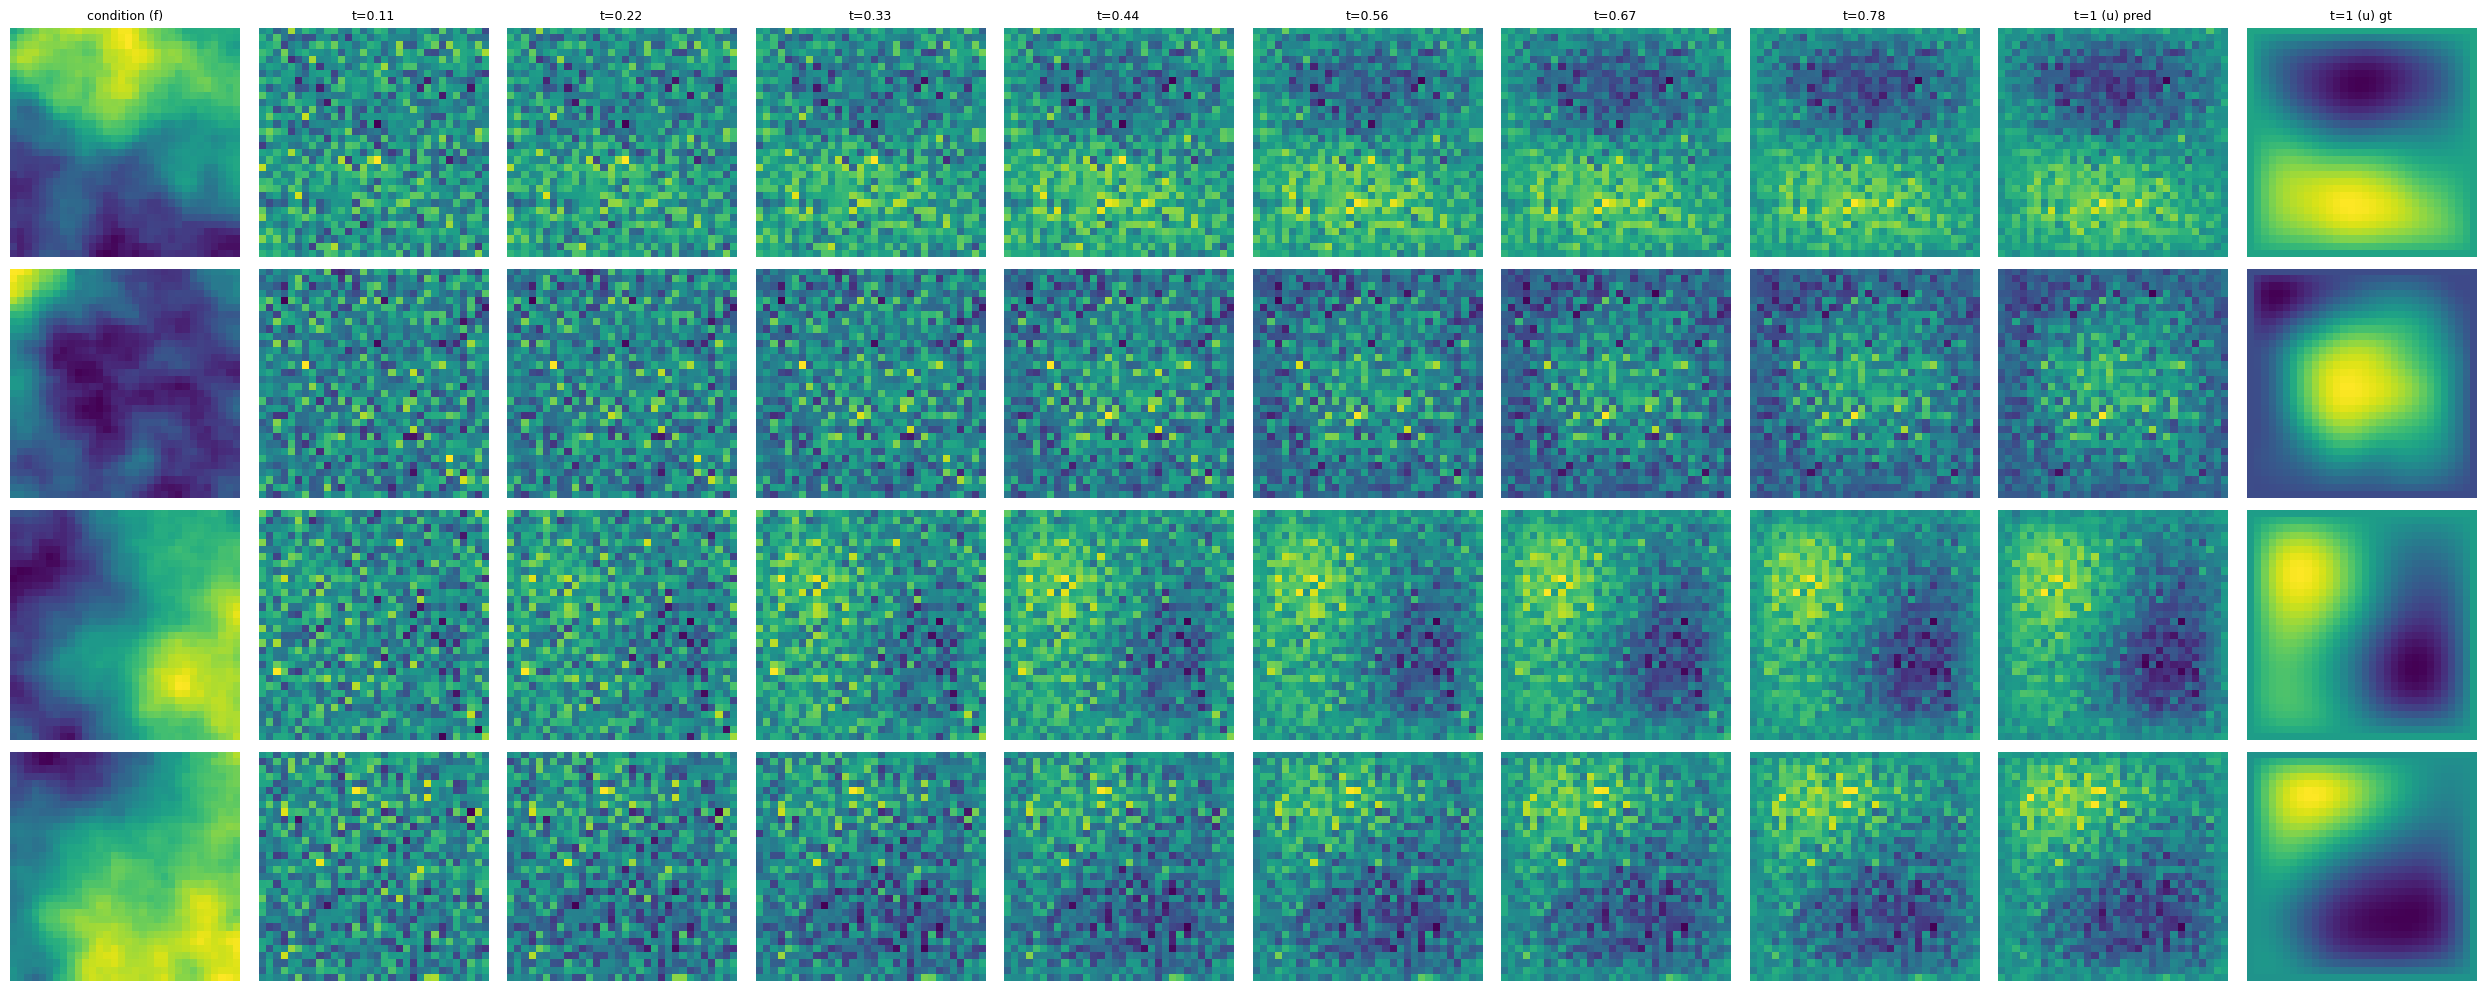

[Epoch 60301/80000] Train Loss: 0.4019034207 | LR: 1.06e-05 | Time: 0.14s
[Epoch 60601/80000] Train Loss: 0.3992907405 | LR: 1.26e-05 | Time: 0.15s
[Epoch 60901/80000] Train Loss: 0.3970412612 | LR: 1.58e-05 | Time: 0.15s
[Epoch 61201/80000] Train Loss: 0.4011346698 | LR: 2.02e-05 | Time: 0.15s
[Epoch 61501/80000] Train Loss: 0.4010253549 | LR: 2.58e-05 | Time: 0.14s
[Epoch 61801/80000] Train Loss: 0.4031186998 | LR: 3.26e-05 | Time: 0.14s
[Epoch 62101/80000] Train Loss: 0.3994864523 | LR: 4.05e-05 | Time: 0.14s
[Epoch 62401/80000] Train Loss: 0.4019517899 | LR: 4.93e-05 | Time: 0.14s
[Epoch 62701/80000] Train Loss: 0.4036363959 | LR: 5.91e-05 | Time: 0.14s
[Epoch 63001/80000] Train Loss: 0.4086764753 | LR: 6.98e-05 | Time: 0.14s
[Epoch 63301/80000] Train Loss: 0.4030583501 | LR: 8.12e-05 | Time: 0.14s
[Epoch 63601/80000] Train Loss: 0.4071073830 | LR: 9.33e-05 | Time: 0.14s
[Epoch 63901/80000] Train Loss: 0.4088000953 | LR: 1.06e-04 | Time: 0.14s
[Epoch 64201/80000] Train Loss: 0.4138

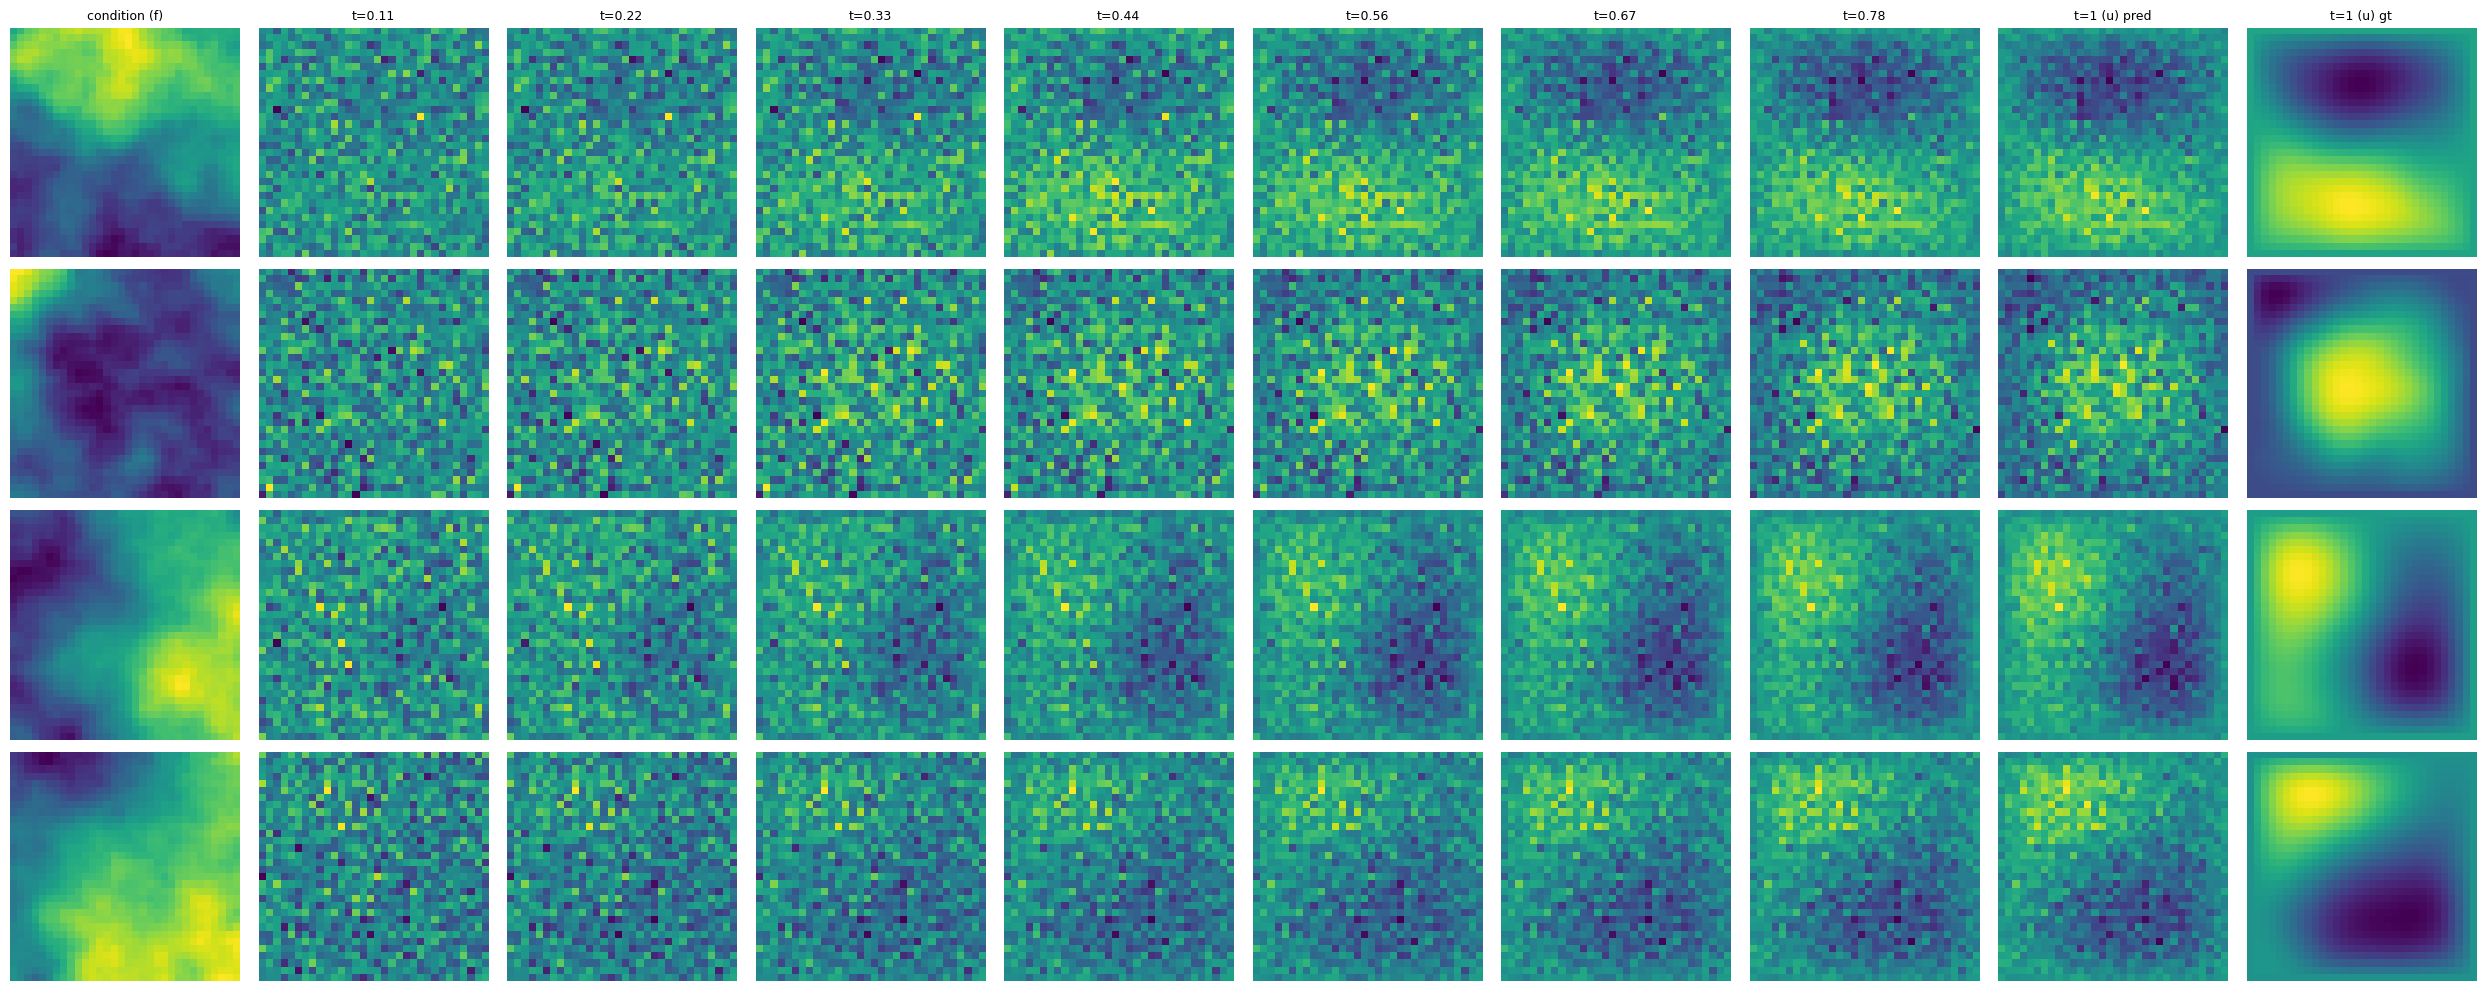

In [27]:
train(
    model=flow,
    data_loader=train_loader,
    optimizer=optimizer,
    lr_schedule=lr_schedule,
    device=device,
    epochs=epochs,
)

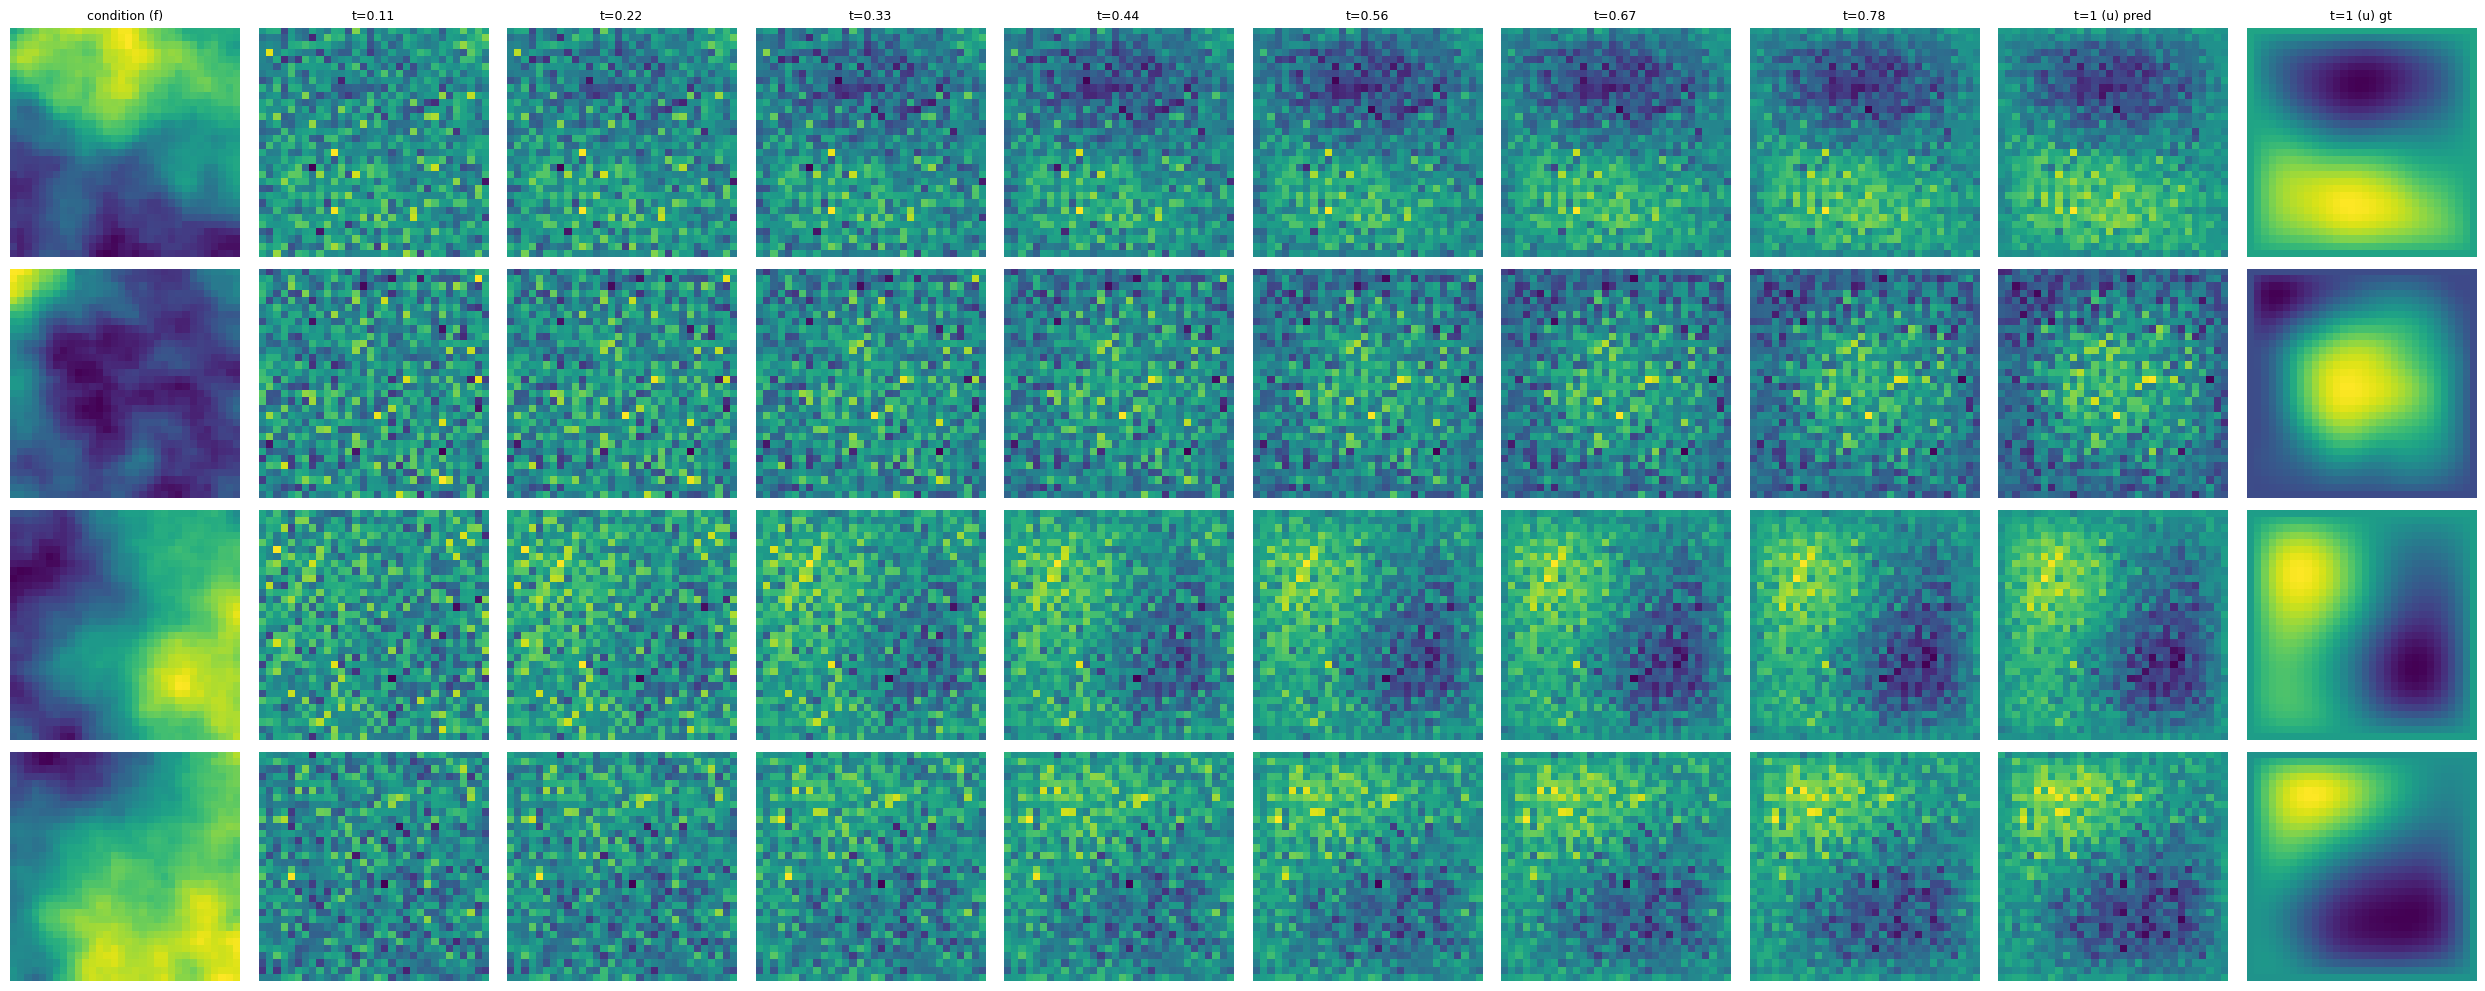

In [28]:
visualize_flow_evolution(flow, val_loader, fig_path="./", n_steps=8, device=device)

In [ ]:
convFlow = ConvFlow(input_dim=16, hidden_dim=32)
convFlow = convFlow.to(device)
optimizer_conv = torch.optim.Adam(convFlow.parameters(), 
                       lr=3e-5)
epochs = 40001
loss_fn_conv = nn.MSELoss()
lr_schedule_conv = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_conv, 
    T_max=epochs, 
    eta_min=1e-6
)

In [ ]:
train(
    model=convFlow,
    data_loader=train_loader,
    optimizer=optimizer_conv,
    lr_schedule=lr_schedule_conv,
    device=device,
    epochs=epochs,
)

In [ ]:
visualize_flow_evolution(convFlow, val_loader, fig_path='./', n_steps=8, device=device)

In [ ]:
UNetFlow = UNetFlow(input_dim=16)
UNetFlow = UNetFlow.to(device)
optimizer_unet = torch.optim.Adam(UNetFlow.parameters(), 
                       lr=3e-4)
epochs = 1001
loss_fn_unet = nn.MSELoss()
lr_schedule_unet = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_unet, 
    T_max=epochs, 
    eta_min=1e-6
)

In [ ]:
torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

In [ ]:
train(
    model=UNetFlow,
    data_loader=train_loader,
    optimizer=optimizer_unet,
    lr_schedule=lr_schedule_unet,
    device=device,
    epochs=epochs,
    save_interval=500
)

In [ ]:
visualize_flow_evolution(UNetFlow, val_loader, fig_path='./', n_steps=8, device=device)